# Starbucks Promotion Optimization
## Phase 2 — Time-Series Feature Engineering

**Goal:** build dynamic features for every *offer instance*, calculated **strictly before the moment the offer is received** (`time < time_received`), so nothing from the offer's own window or later leaks into the model.

| Feature | Definition used here |
|---|---|
| **Offer fatigue** | Offers received by the customer in the trailing 14 and 30 days before `time_received` |
| **Inter-purchase time (IPT)** | Average gap (days) between the customer's *organic* purchases before `time_received`. Reported as the full-history mean and a rolling mean of the last 3 gaps |
| **Reward hunting index** | Spend during active-offer periods ÷ spend during non-offer periods (smoothed). Plus an exposure-adjusted per-day version |
| **Time-decayed AOV** | Exponentially weighted average order value, half-life 7 days |

**Definitions that apply to several features**
- *Offer period* = a transaction made while a **viewed** BOGO or discount offer was still active (`time_viewed ≤ t ≤ offer_end`). An offer the customer never saw cannot influence their purchase (same reasoning as the Phase 1 view trap). Informational offers carry no price incentive, so they do **not** count as offer periods.
- *Organic transaction* = any transaction outside an offer period.
- *Strictly prior* = transactions and offers with `time < time_received` (a purchase in the same hour as the offer arrives is excluded).
- The data covers 30 days and offers go out in 6 waves (hours 0, 168, 336, 408, 504, 576), so features are computed once per (customer, wave) and shared by offers sent in the same wave.

In [2]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("../outputs")          # Phase 1 outputs live here

# ---- feature parameters (change here, everything below follows) ----
FATIGUE_WINDOWS_DAYS = (14, 30)
IPT_ROLLING_GAPS     = 3        # rolling IPT = mean of the last 3 gaps
HALF_LIFE_DAYS       = 7        # time-decay half-life for AOV
RHI_SMOOTHING        = 1.0      # $ added to numerator and denominator of the spend ratio
HOURS = 24
print("Config loaded.")

Config loaded.


In [3]:
# ============================================================
# LOAD PHASE 1 OUTPUTS
# ============================================================
instances = pd.read_csv(OUTPUT_DIR / "customer_offer_instances.csv")
tx_raw    = pd.read_csv(OUTPUT_DIR / "attributed_transactions.csv")

need_inst = {"person_id", "offer_id", "instance_id", "time_received", "time_viewed", "offer_end", "offer_type"}
need_tx   = {"person_id", "transaction_time", "amount"}
assert need_inst <= set(instances.columns), need_inst - set(instances.columns)
assert need_tx   <= set(tx_raw.columns),    need_tx - set(tx_raw.columns)
assert instances["instance_id"].is_unique

tx = (tx_raw[["person_id", "transaction_time", "amount"]]
      .sort_values(["person_id", "transaction_time"]).reset_index(drop=True))

print("Offer instances :", f"{len(instances):,}")
print("Transactions    :", f"{len(tx):,}")
print("Offer waves (hours):", sorted(instances["time_received"].unique()))

Offer instances : 76,277
Transactions    : 138,953
Offer waves (hours): [np.int64(0), np.int64(168), np.int64(336), np.int64(408), np.int64(504), np.int64(576)]


In [4]:
# ============================================================
# ONE ROW PER (CUSTOMER, WAVE) — features are shared by offers sent together
# ============================================================
snap = (instances[["person_id", "time_received"]]
        .drop_duplicates().sort_values(["person_id", "time_received"]).reset_index(drop=True))
print("Customer-wave snapshots:", f"{len(snap):,}  (offer instances: {len(instances):,})")

Customer-wave snapshots: 76,277  (offer instances: 76,277)


## Step 0 — Separate offer-period spending from organic spending
Needed by IPT (organic only) and the reward hunting index. Uses only view and expiry times, so it never depends on anything after the transaction itself.

In [5]:
# ============================================================
# FLAG TRANSACTIONS MADE DURING AN ACTIVE, VIEWED REWARD OFFER
# ============================================================
def flag_offer_period(tx, instances):
    """True when a VIEWED bogo/discount offer was active at the transaction time."""
    rv = instances[instances["offer_type"].isin(["bogo", "discount"])
                   & instances["time_viewed"].notna()
                   & (instances["time_viewed"] <= instances["offer_end"])]
    rv_by = {p: (g["time_viewed"].values, g["offer_end"].values) for p, g in rv.groupby("person_id")}

    flags = np.zeros(len(tx), dtype=bool)
    t_all = tx["transaction_time"].values
    for p, idx in tx.groupby("person_id").indices.items():
        if p in rv_by:
            tv, te = rv_by[p]
            t = t_all[idx]
            flags[idx] = ((tv[None, :] <= t[:, None]) & (t[:, None] <= te[None, :])).any(axis=1)
    return flags

tx["in_offer_period"] = flag_offer_period(tx, instances)

print(f"Transactions in an offer period : {tx['in_offer_period'].sum():,} ({tx['in_offer_period'].mean():.1%})")
print(f"Organic transactions            : {(~tx['in_offer_period']).sum():,} ({(~tx['in_offer_period']).mean():.1%})")
print()
print(tx.groupby("in_offer_period")["amount"].agg(["count", "mean", "median"]).round(2))

Transactions in an offer period : 96,767 (69.6%)
Organic transactions            : 42,186 (30.4%)

                 count   mean  median
in_offer_period                      
False            42186  12.46    8.50
True             96767  12.92    9.05


## Feature 1 — Offer fatigue
Number of offers **received** in the 14 and 30 days *before* the new offer arrives.
Note: the whole dataset spans 30 days, so the 30-day count equals "all offers received so far". Wave 1 (hour 0) is always 0 for everyone.

In [6]:
# ============================================================
# FEATURE 1 — OFFER FATIGUE (trailing 14 / 30 days)
# ============================================================
def feat_fatigue(snap, instances):
    rec_by = {p: np.sort(g["time_received"].values) for p, g in instances.groupby("person_id")}
    rows = []
    for p, T in zip(snap["person_id"], snap["time_received"]):
        r = rec_by[p]
        k_all = np.searchsorted(r, T, side="left")                 # offers received strictly before T
        row = [k_all]
        for d in FATIGUE_WINDOWS_DAYS:
            row.append(k_all - np.searchsorted(r, T - d * HOURS, side="left"))
        rows.append(row)
    cols = ["offers_prior_all"] + [f"offers_received_{d}d" for d in FATIGUE_WINDOWS_DAYS]
    out = snap[["person_id", "time_received"]].copy()
    out[cols] = rows
    return out

fatigue = feat_fatigue(snap, instances)
print(fatigue.drop(columns=["person_id"]).groupby("time_received").mean().round(2))

               offers_prior_all  offers_received_14d  offers_received_30d
time_received                                                            
0                          0.00                 0.00                 0.00
168                        0.74                 0.74                 0.74
336                        1.50                 1.50                 1.50
408                        2.24                 1.50                 2.24
504                        3.00                 2.25                 3.00
576                        3.74                 2.25                 3.74


## Feature 2 — Inter-purchase time (organic)
Average days between consecutive **organic** purchases before the offer arrives. Needs at least 2 prior organic purchases (otherwise left empty, which tree models handle natively). Also gives `days_since_last_organic_tx`.

In [7]:
# ============================================================
# FEATURE 2 — INTER-PURCHASE TIME (organic transactions only)
# ============================================================
def feat_ipt(snap, tx):
    org_by = {p: g["transaction_time"].values for p, g in tx[~tx["in_offer_period"]].groupby("person_id")}
    empty = np.array([])
    rows = []
    for p, T in zip(snap["person_id"], snap["time_received"]):
        o = org_by.get(p, empty)
        k = np.searchsorted(o, T, side="left")                    # organic tx strictly before T
        ipt_all = ipt_roll = np.nan
        if k >= 2:
            gaps = np.diff(o[:k]) / HOURS
            ipt_all  = gaps.mean()
            ipt_roll = gaps[-IPT_ROLLING_GAPS:].mean()
        since = (T - o[k - 1]) / HOURS if k >= 1 else np.nan
        rows.append((k, ipt_all, ipt_roll, since))
    out = snap[["person_id", "time_received"]].copy()
    out[["n_prior_organic_tx", "ipt_days", f"ipt_days_last{IPT_ROLLING_GAPS}", "days_since_last_organic_tx"]] = rows
    return out

ipt = feat_ipt(snap, tx)
print(ipt.drop(columns=["person_id"]).groupby("time_received").agg(["mean"]).round(2))
print()
print("Share with IPT available:", f"{ipt['ipt_days'].notna().mean():.1%}")

              n_prior_organic_tx ipt_days ipt_days_last3 days_since_last_organic_tx
                            mean     mean           mean                       mean
time_received                                                                      
0                           0.00      NaN            NaN                        NaN
168                         0.60     2.16           2.16                       3.20
336                         1.23     3.54           3.55                       5.47
408                         1.56     4.20           4.21                       5.96
504                         1.85     4.64           4.64                       7.75
576                         2.08     5.08           5.08                       8.99

Share with IPT available: 32.4%


## Feature 3 — Reward hunting index
`(spend in offer periods + k) / (spend in non-offer periods + k)` using only purchases before the offer arrives. Smoothing `k` avoids dividing by zero and shrinks tiny-sample ratios toward 1.

Because a customer can spend more in offer periods simply by being *exposed* for longer, an exposure-adjusted version is also built: spend **per day** during offer periods ÷ spend per day outside them (left empty unless both groups have spend and exposure).

In [8]:
# ============================================================
# FEATURE 3 — REWARD HUNTING INDEX
# ============================================================
def union_hours(starts, ends):
    """Total length covered by a set of possibly-overlapping intervals."""
    order = np.argsort(starts)
    s, e = starts[order], ends[order]
    total, cs, ce = 0.0, s[0], e[0]
    for a, b in zip(s[1:], e[1:]):
        if a <= ce:
            ce = max(ce, b)
        else:
            total += ce - cs
            cs, ce = a, b
    return total + (ce - cs)

def feat_rhi(snap, tx, instances):
    rv = instances[instances["offer_type"].isin(["bogo", "discount"])
                   & instances["time_viewed"].notna()
                   & (instances["time_viewed"] <= instances["offer_end"])]
    rv_by = {p: (g["time_viewed"].values, g["offer_end"].values) for p, g in rv.groupby("person_id")}

    tx_by = {}
    for p, g in tx.groupby("person_id"):
        amt, f = g["amount"].values, g["in_offer_period"].values
        tx_by[p] = (g["transaction_time"].values,
                    np.concatenate([[0.0], np.cumsum(amt * f)]),      # cumulative offer-period spend
                    np.concatenate([[0.0], np.cumsum(amt * ~f)]))     # cumulative organic spend
    rows = []
    for p, T in zip(snap["person_id"], snap["time_received"]):
        off_sp = org_sp = 0.0
        k = 0
        if p in tx_by:
            t, cs_off, cs_org = tx_by[p]
            k = np.searchsorted(t, T, side="left")                    # strictly before T
            off_sp, org_sp = cs_off[k], cs_org[k]
        # hours the customer was under a *viewed* reward offer before T
        off_h = 0.0
        if p in rv_by:
            tv, te = rv_by[p]
            m = tv < T                                                # only views already known at T
            if m.any():
                off_h = union_hours(tv[m], np.minimum(te[m], T))
        org_h = T - off_h
        rhi = (off_sp + RHI_SMOOTHING) / (org_sp + RHI_SMOOTHING)
        rhi_rate = ((off_sp / off_h) / (org_sp / org_h)
                    if off_sp > 0 and org_sp > 0 and off_h > 0 and org_h > 0 else np.nan)
        rows.append((off_sp, org_sp, off_h / HOURS, rhi, rhi_rate))
    out = snap[["person_id", "time_received"]].copy()
    out[["prior_offer_period_spend", "prior_organic_spend", "prior_offer_exposure_days",
         "reward_hunting_index", "reward_hunting_index_per_day"]] = rows
    return out

rhi = feat_rhi(snap, tx, instances)
print(rhi.drop(columns=["person_id"]).groupby("time_received").mean().round(2))

               prior_offer_period_spend  prior_organic_spend  prior_offer_exposure_days  reward_hunting_index  \
time_received                                                                                                   
0                                  0.00                 0.00                       0.00                  1.00   
168                               12.01                 7.41                       2.45                 10.93   
336                               26.31                15.13                       5.17                 15.51   
408                               32.68                19.10                       6.32                 14.93   
504                               45.85                22.38                       8.70                 17.21   
576                               55.86                25.69                      10.41                 17.94   

               reward_hunting_index_per_day  
time_received                                
0  

## Feature 4 — Time-decayed average order value
Weighted mean of past order values where each purchase's weight is `exp(-λ · age_in_days)` and `λ = ln(2) / half-life`. A 7-day half-life means a purchase from a week ago counts half as much as one made right now. Plain AOV is kept alongside for comparison.

In [9]:
# ============================================================
# FEATURE 4 — TIME-DECAYED AOV
# ============================================================
def feat_decay_aov(snap, tx, half_life_days=HALF_LIFE_DAYS):
    lam = np.log(2) / half_life_days
    tx_by = {p: (g["transaction_time"].values, g["amount"].values) for p, g in tx.groupby("person_id")}
    rows = []
    for p, T in zip(snap["person_id"], snap["time_received"]):
        n, aov_plain, aov_dec = 0, np.nan, np.nan
        if p in tx_by:
            t, amt = tx_by[p]
            n = np.searchsorted(t, T, side="left")                    # strictly before T
            if n > 0:
                w = np.exp(-lam * (T - t[:n]) / HOURS)
                aov_dec, aov_plain = (w @ amt[:n]) / w.sum(), amt[:n].mean()
        rows.append((n, aov_plain, aov_dec))
    out = snap[["person_id", "time_received"]].copy()
    out[["n_prior_tx", "aov_plain", f"aov_decayed_hl{half_life_days}d"]] = rows
    return out

aov = feat_decay_aov(snap, tx)
print(aov.drop(columns=["person_id"]).groupby("time_received").mean().round(2))

               n_prior_tx  aov_plain  aov_decayed_hl7d
time_received                                         
0                    0.00        NaN               NaN
168                  1.53      13.14             13.13
336                  3.26      13.51             13.51
408                  4.11      13.40             13.37
504                  5.42      13.48             13.46
576                  6.38      13.68             13.75


## Assemble the feature table
One function builds everything from (instances, transactions, snapshots), so the leakage test below can re-run exactly the same code on truncated data.

In [10]:
# ============================================================
# ASSEMBLE ALL FEATURES
# ============================================================
KEYS = ["person_id", "time_received"]

def build_features(instances, tx, snap):
    tx = tx.copy()
    tx["in_offer_period"] = flag_offer_period(tx, instances)
    f = feat_fatigue(snap, instances)
    for part in (feat_ipt(snap, tx), feat_rhi(snap, tx, instances), feat_decay_aov(snap, tx)):
        f = f.merge(part, on=KEYS, how="left")
    f["has_purchase_history"] = (f["n_prior_tx"] > 0).astype(int)
    return f

features = build_features(instances, tx[["person_id", "transaction_time", "amount"]], snap)

carry = [c for c in ["instance_id", "person_id", "offer_id", "offer_type", "time_received", "time_viewed",
                     "time_completed", "viewed", "completed", "view_status", "accidental_completion",
                     "window_spend", "difficulty", "duration", "offer_reward"] if c in instances.columns]
model_table = instances[carry].merge(features, on=KEYS, how="left", validate="many_to_one")

assert len(model_table) == len(instances)
assert model_table["instance_id"].is_unique
print("Feature table :", features.shape, " | model table:", model_table.shape)
FEATURE_COLS = [c for c in features.columns if c not in KEYS]
print("\nFeatures:", FEATURE_COLS)

Feature table : (76277, 18)  | model table: (76277, 31)

Features: ['offers_prior_all', 'offers_received_14d', 'offers_received_30d', 'n_prior_organic_tx', 'ipt_days', 'ipt_days_last3', 'days_since_last_organic_tx', 'prior_offer_period_spend', 'prior_organic_spend', 'prior_offer_exposure_days', 'reward_hunting_index', 'reward_hunting_index_per_day', 'n_prior_tx', 'aov_plain', 'aov_decayed_hl7d', 'has_purchase_history']


## Leakage test (the important one)
For a random sample of customer-waves, throw away **everything the model should not know at that moment** and rebuild the features from scratch:
- transactions at or after `time_received`,
- offers received after `time_received`,
- views that happen at or after `time_received` (not yet known).

If any feature quietly used future information, the truncated rebuild would give a different number. They must match exactly.

In [11]:
# ============================================================
# LEAKAGE TEST — rebuild each feature from past-only data and compare
# ============================================================
rng = np.random.default_rng(42)
sample = snap.sample(400, random_state=42)

tx_cols   = ["person_id", "transaction_time", "amount"]
tx_empty  = tx[tx_cols].iloc[0:0]
tx_by_p   = {p: g for p, g in tx[tx_cols].groupby("person_id")}
inst_by_p = {p: g for p, g in instances.groupby("person_id")}
full = features.set_index(KEYS)

test_cols = [c for c in FEATURE_COLS if c != "has_purchase_history"]
max_diff, mismatches = 0.0, 0

for p, T in zip(sample["person_id"], sample["time_received"]):
    # ---- keep only what was knowable before T ----
    tx_past = tx_by_p.get(p, tx_empty).query("transaction_time < @T")
    inst_past = inst_by_p[p].query("time_received <= @T").copy()               # offers up to the moment of T
    inst_past.loc[inst_past["time_viewed"] >= T, "time_viewed"] = np.nan      # views not yet happened
    one = pd.DataFrame({"person_id": [p], "time_received": [T]})

    rebuilt = build_features(inst_past, tx_past, one).set_index(KEYS).loc[(p, T), test_cols]
    ref = full.loc[(p, T), test_cols]

    nan_pattern_same = (ref.isna().values == rebuilt.isna().values).all()
    d = np.nanmax(np.abs(ref.values.astype(float) - rebuilt.values.astype(float)))
    if not nan_pattern_same or d > 1e-9:
        mismatches += 1
    max_diff = max(max_diff, 0 if np.isnan(d) else d)

print(f"Customer-waves tested : {len(sample)}")
print(f"Mismatches            : {mismatches}")
print(f"Largest difference    : {max_diff:.2e}")
assert mismatches == 0, "Leakage detected: a feature changed when future data was removed."
print("PASS — features use only information available before the offer arrives.")

Customer-waves tested : 400
Mismatches            : 0
Largest difference    : 0.00e+00
PASS — features use only information available before the offer arrives.


## Quality checks and what the features look like

In [12]:
# ============================================================
# COVERAGE BY WAVE — early waves have little history to work with
# ============================================================
by_wave = model_table.groupby("time_received").agg(
    instances=("instance_id", "size"),
    has_history=("has_purchase_history", "mean"),
    ipt_available=("ipt_days", lambda s: s.notna().mean()),
    rhi_rate_available=("reward_hunting_index_per_day", lambda s: s.notna().mean()),
    mean_offers_14d=("offers_received_14d", "mean"),
    mean_prior_tx=("n_prior_tx", "mean"),
).round(3)
display(by_wave)
print("Wave 1 (hour 0) has no history for anyone — keep `has_purchase_history` as a model input rather than imputing.")

,instances,has_history,ipt_available,rhi_rate_available,mean_offers_14d,mean_prior_tx
time_received,,,,,,
0,12650,0.000,0.000,0.000,0.000,0.000
168,12669,0.662,0.149,0.059,0.742,1.532
336,12711,0.870,0.336,0.322,1.495,3.263
408,12778,0.909,0.423,0.457,1.498,4.109
504,12704,0.944,0.491,0.580,2.253,5.421
576,12765,0.962,0.543,0.656,2.249,6.377


Wave 1 (hour 0) has no history for anyone — keep `has_purchase_history` as a model input rather than imputing.


In [13]:
# ============================================================
# SANITY RANGES
# ============================================================
assert (model_table[["offers_received_14d", "offers_received_30d", "n_prior_tx"]] >= 0).all().all()
assert (model_table["offers_received_30d"] >= model_table["offers_received_14d"]).all()
assert (model_table["aov_plain"].dropna() > 0).all()
assert (model_table["ipt_days"].dropna() >= 0).all()
assert (model_table["reward_hunting_index"] > 0).all()

display(model_table[FEATURE_COLS].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
offers_prior_all,76277.0,1.87,1.45,0.00,1.00,2.00,3.00,5.00
offers_received_14d,76277.0,1.38,1.00,0.00,1.00,1.00,2.00,3.00
offers_received_30d,76277.0,1.87,1.45,0.00,1.00,2.00,3.00,5.00
n_prior_organic_tx,76277.0,1.22,1.60,0.00,0.00,1.00,2.00,15.00
ipt_days,24741.0,4.29,3.36,0.25,2.00,3.44,5.62,23.75
ipt_days_last3,24741.0,4.29,3.38,0.25,1.88,3.50,5.75,23.75
days_since_last_organic_tx,40972.0,6.69,5.24,0.25,2.50,5.50,9.75,24.00
prior_offer_period_spend,76277.0,28.84,66.28,0.00,0.00,2.70,32.85,1214.37
prior_organic_spend,76277.0,14.98,36.27,0.00,0.00,1.66,18.68,1024.04
prior_offer_exposure_days,76277.0,5.52,5.47,0.00,0.00,5.00,9.25,24.00


In [14]:
# ============================================================
# DECAY SENSITIVITY — does the half-life choice matter?
# ============================================================
check = snap.merge(feat_decay_aov(snap, tx, 3), on=KEYS).merge(feat_decay_aov(snap, tx, 14), on=KEYS, suffixes=("_3", "_14"))
cols = [c for c in check.columns if c.startswith("aov_decayed")]
merged = features[KEYS + ["aov_plain", f"aov_decayed_hl{HALF_LIFE_DAYS}d"]].merge(check[KEYS + cols], on=KEYS)
print("Correlation between AOV versions (customers with history):")
display(merged.drop(columns=KEYS).corr().round(3))

Correlation between AOV versions (customers with history):


,aov_plain,aov_decayed_hl7d,aov_decayed_hl3d,aov_decayed_hl14d
aov_plain,1.000,0.964,0.872,0.990
aov_decayed_hl7d,0.964,1.000,0.969,0.991
aov_decayed_hl3d,0.872,0.969,1.000,0.929
aov_decayed_hl14d,0.990,0.991,0.929,1.000


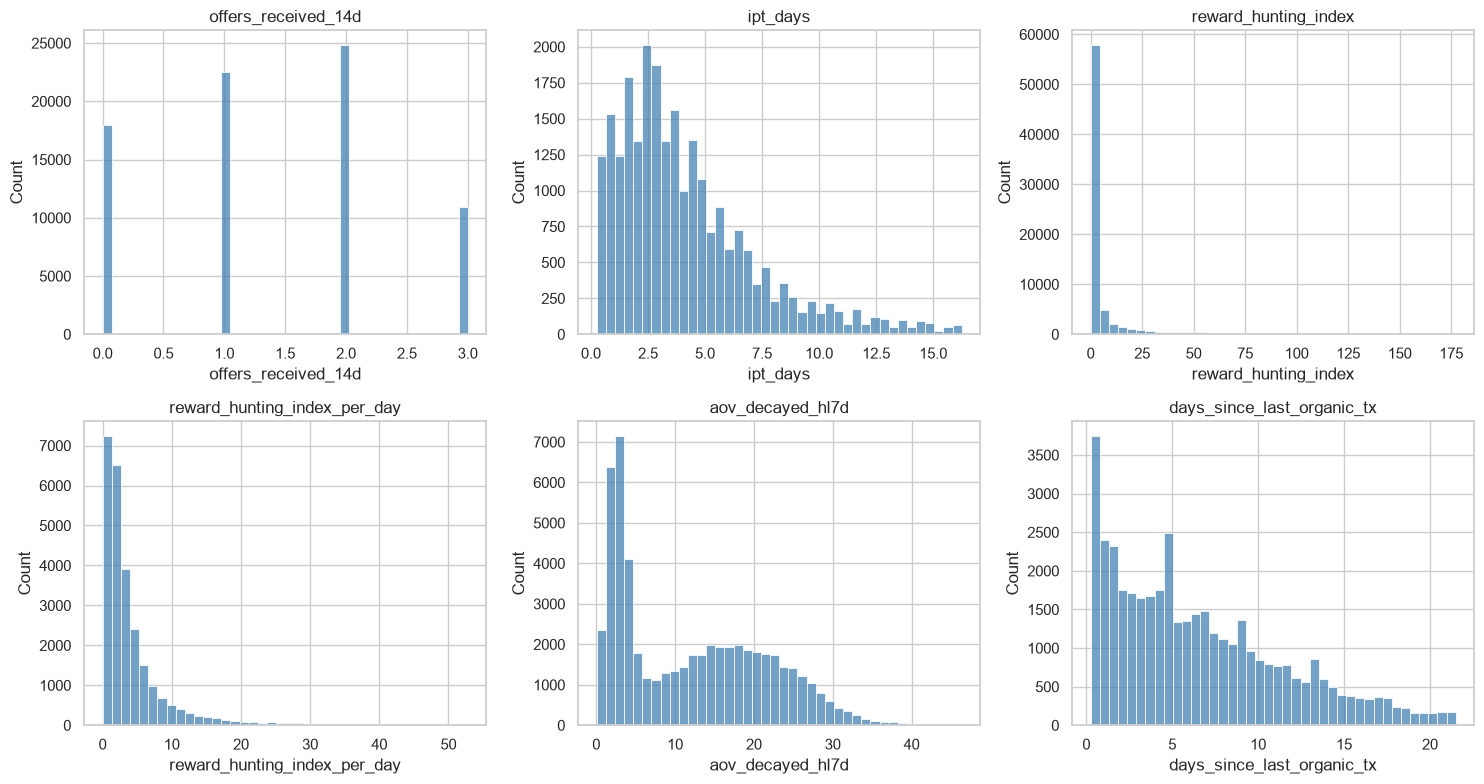

In [15]:
# ============================================================
# DISTRIBUTIONS
# ============================================================
plot_cols = ["offers_received_14d", "ipt_days", "reward_hunting_index", "reward_hunting_index_per_day",
             f"aov_decayed_hl{HALF_LIFE_DAYS}d", "days_since_last_organic_tx"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    s = features[col].dropna()
    s = s[s <= s.quantile(0.99)]                                  # trim extreme tail for display only
    sns.histplot(s, bins=40, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
Path("../figures/phase2").mkdir(parents=True, exist_ok=True)
plt.savefig("../figures/phase2/feature_distributions.png", dpi=120)
plt.show()

In [16]:
# ============================================================
# BALANCE CHECK — do viewers and non-viewers look alike BEFORE the offer?
# (Viewing is not randomised, so this tells Phase 3 how much confounding to expect.)
# ============================================================
promo = model_table[model_table["offer_type"].isin(["bogo", "discount"])]
treated = (promo["viewed"] == 1) & (promo["accidental_completion"] == 0)

balance = promo.groupby(treated.map({True: "treated (viewed first)", False: "control"}))[
    ["offers_received_14d", "n_prior_tx", "ipt_days", "reward_hunting_index", f"aov_decayed_hl{HALF_LIFE_DAYS}d"]
].mean().round(2).T
balance["abs_gap_%"] = ((balance["treated (viewed first)"] - balance["control"]).abs()
                        / balance["control"].abs() * 100).round(1)
display(balance)

,control,treated (viewed first),abs_gap_%
offers_received_14d,1.46,1.34,8.2
n_prior_tx,3.83,3.29,14.1
ipt_days,4.31,4.28,0.7
reward_hunting_index,14.27,12.13,15.0
aov_decayed_hl7d,13.79,13.21,4.2


## Save outputs for Phase 3

In [17]:
# ============================================================
# SAVE
# ============================================================
features.to_csv(OUTPUT_DIR / "phase2_features_by_customer_wave.csv", index=False)
model_table.to_csv(OUTPUT_DIR / "phase2_model_table.csv", index=False)
print("Saved:")
print(" -", OUTPUT_DIR / "phase2_features_by_customer_wave.csv", features.shape)
print(" -", OUTPUT_DIR / "phase2_model_table.csv", model_table.shape)

Saved:
 - ..\outputs\phase2_features_by_customer_wave.csv (76277, 18)
 - ..\outputs\phase2_model_table.csv (76277, 31)


# Phase 2 Conclusions

1. **Point-in-time features.** Every feature is calculated per customer and per offer wave using only events with `time < time_received`. A truncation test (rebuilding 400 customer-waves from past-only data) reproduced every value exactly.
2. **Offer fatigue** counts offers received in the trailing 14 and 30 days. Because the data spans only 30 days, the 30-day count is effectively "all offers so far".
3. **Inter-purchase time** uses organic purchases only (outside viewed reward-offer windows), as a full-history mean and a rolling mean of the last 3 gaps.
4. **Reward hunting index** compares offer-period and organic spending, smoothed to avoid division by zero, plus an exposure-adjusted per-day version.
5. **Time-decayed AOV** weights recent orders more (7-day half-life). It tracks plain AOV closely but reacts to recent changes in basket size.
6. **Limitations.** Wave 1 has no history for anyone; early waves have thin history; the half-life, smoothing constant and rolling-gap count are choices (sensitivity checked for the half-life).

Outputs for Phase 3: `phase2_model_table.csv` (one row per offer instance, features attached).